# Final Part  — Out-of-Sample Generalization and Robustness Analysis
## <b> ADRIAN VAZQUEZ </b>
---

In [1]:
# libs
import plotly.io as pio
#pio.renderers.default = "notebook_connected+png" 

from IPython.display import Image, display
import sys
import os
# Add project root to path
sys.path.append(os.path.abspath(".."))

# libs 
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# RF 
import torch
import torch.nn as nn
import torch.optim as optim

from src.models.twap import twap_schedule
from src.models.vwap import generate_vwap_schedule
from src.models.inventory_from_schedule import inventory_from_schedule
from src.models.almgren_chriss_shedule import almgren_chriss_schedule
from src.analytics.implementation_shortfall import implementation_shortfall
from src.analytics.get_intraday_prices import get_intraday_prices
from src.models.simulate_brownian_motion_price_path import simulate_brownian_price_path, simulate_multiple_price_paths, simulate_execution_prices
from src.models.volume_aware_ac_schedule import volume_aware_ac_schedule
from src.analytics.get_long_term_intraday_prices import get_intraday_prices, get_intraday_prices_multiple_months


# <b> Data Acquisition  </b> 

In [2]:
#  Download intraday market data
API_KEY = "M617ZETAG1ZHY6I6"

months = [
    "2026-03",
    "2026-04",
    "2026-05"
]

df_spy_5min = get_intraday_prices_multiple_months(
    symbol="SPY",
    api_key=API_KEY,
    months=months,
    interval="5min",
    adjusted="true",
    extended_hours="false"
)

df_spy_5min.head(), df_spy_5min.tail()

(                         Open      High       Low     Close   Volume symbol  \
 2026-03-02 09:30:00  676.8247  679.5970  676.1466  679.3178  2875190    SPY   
 2026-03-02 09:35:00  679.3278  680.5743  678.9488  679.1271  2295214    SPY   
 2026-03-02 09:40:00  679.1134  680.4533  679.0984  680.1954  1257231    SPY   
 2026-03-02 09:45:00  680.1854  681.4818  679.8677  681.3322  1706310    SPY   
 2026-03-02 09:50:00  681.3422  681.4220  679.9959  680.6242  1633498    SPY   
 
                     source_month  
 2026-03-02 09:30:00      2026-03  
 2026-03-02 09:35:00      2026-03  
 2026-03-02 09:40:00      2026-03  
 2026-03-02 09:45:00      2026-03  
 2026-03-02 09:50:00      2026-03  ,
                        Open    High     Low    Close   Volume symbol  \
 2026-05-27 15:35:00  750.56  750.88  750.53  750.770   311746    SPY   
 2026-05-27 15:40:00  750.76  750.87  750.50  750.860   396809    SPY   
 2026-05-27 15:45:00  750.86  750.86  750.31  750.311   738935    SPY   
 2026-05-

In [3]:
df_spy_5min["date"] = df_spy_5min.index.date

print("Number of rows:", len(df_spy_5min))
print("Number of trading days:", df_spy_5min["date"].nunique())
print(df_spy_5min["date"].min(), df_spy_5min["date"].max())

Number of rows: 4758
Number of trading days: 61
2026-03-02 2026-05-27


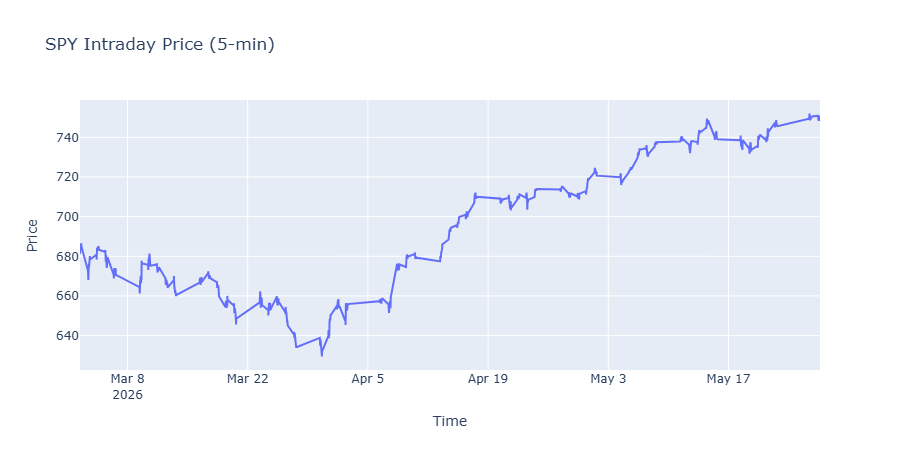

In [6]:
# plot
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=df_spy_5min.index,
        y=df_spy_5min["Close"],
        mode="lines",
        name="SPY Close"
    )
)
fig.update_layout(
    title="SPY Intraday Price (5-min)",
    xaxis_title="Time",
    yaxis_title="Price",
    height=450,
    width=900
)
fig.show()
fig.write_image("../results/plots/2_SPY_Intraday_Price_5min.png")
display(Image(filename="../results/plots/2_SPY_Intraday_Price_5min.png"))

In [4]:
# Cleaning
df_spy_5min.index = pd.to_datetime(df_spy_5min.index)

df_spy_5min = (
    df_spy_5min
    .sort_index()
    .loc[~df_spy_5min.index.duplicated()]
)

df_spy_5min = df_spy_5min.between_time("09:30", "15:55")


# Market feature engineering
df_market_state = df_spy_5min.copy()


# Price dynamics
df_market_state["returns"] = df_market_state["Close"].pct_change()

df_market_state["rolling_vol"] = (
    df_market_state["returns"]
    .rolling(window=20)
    .std()
)

df_market_state["momentum"] = (
    df_market_state["Close"]
    - df_market_state["Close"].rolling(window=5).mean()
)

# Liquidity dynamics
df_market_state["rel_volume"] = (
    df_market_state["Volume"]
    / df_market_state["Volume"].rolling(window=20).mean()
)

df_market_state["minute_of_day"] = (
    df_market_state.index.hour * 60
    + df_market_state.index.minute
)

volume_profile = (
    df_market_state
    .groupby("minute_of_day")["Volume"]
    .mean()
)

df_market_state["volume_profile"] = (
    df_market_state["minute_of_day"]
    .map(volume_profile)
)

df_market_state["volume_profile_norm"] = (
    df_market_state["volume_profile"]
    / df_market_state["volume_profile"].mean()
)

# Friction proxy
df_market_state["spread_proxy"] = (
    df_market_state["High"]
    - df_market_state["Low"]
)

df_market_state["spread_proxy_pct"] = (
    df_market_state["spread_proxy"]
    / df_market_state["Close"]
)

# Final RL market state dataset

market_feature_cols = [
    "returns",
    "rolling_vol",
    "momentum",
    "rel_volume",
    "volume_profile_norm",
    "spread_proxy_pct"
]

df_market_state = df_market_state.dropna(
    subset=market_feature_cols
)

print("Market state dataset shape:", df_market_state.shape)
print("Start:", df_market_state.index.min())
print("End:", df_market_state.index.max())

df_market_state[market_feature_cols].head()

Market state dataset shape: (4738, 17)
Start: 2026-03-02 11:10:00
End: 2026-05-27 15:55:00


,returns,rolling_vol,momentum,rel_volume,volume_profile_norm,spread_proxy_pct
2026-03-02 11:10:00,-0.000292,0.000996,0.68812,0.957896,0.832850,0.000744
2026-03-02 11:15:00,-0.000832,0.001021,-0.15354,0.478937,0.973858,0.000990
2026-03-02 11:20:00,-0.000117,0.000976,-0.32110,0.511604,0.899565,0.000774
2026-03-02 11:25:00,-0.002089,0.001036,-1.45600,1.396308,0.891603,0.002620
2026-03-02 11:30:00,0.000893,0.001024,-0.51462,0.846522,0.842128,0.001521


# <b> Reusing RL Execution Components. </b> 

To keep this notebook focused on out-of-sample evaluation and robustness analysis, the main classes and functions developed in the previous section are now moved into a reusable Python module.

The logic remains unchanged. The only difference is that the implementation is now packaged inside:

```python

## <b> Calling the classes and functions that  we have been using so far from '05_RL_Execution_agent.py' </b>

They are the exact same functions; the only difference is that now we have  packed them into a .py file.

The Classes and fucntions are: 
 
- StateBuilder() class 
  1. buil_state
- ExecutionEnv() class
  1. get_execution_history
- run_random_policy
- run_twap_policy
- run_vwap_like_policy
- run_volume_aware_ac_policy
- DQN () class
  1. forward 
- ReplayBuffer() class
  1. push 
  2. sample
- select_action
- update_target_network
- train_dqn_step   <- <b> Here, we are goin to train the agent over many days  </b>
- run_dqn_policy


In [12]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.models.RL_Execution import (
    StateBuilder,
    ExecutionEnv,
    run_random_policy,
    run_twap_policy,
    run_vwap_like_policy,
    run_volume_aware_ac_policy,
    DQN,
    ReplayBuffer,
    select_action,
    update_target_network,
    train_dqn_step,
    run_dqn_policy
)

# <b> Did the agent learn a generalizable policy? </b>

In [7]:
# temporal split : 

df_market_state["date"] = df_market_state.index.date

unique_days = sorted(df_market_state["date"].unique())

train_days = unique_days[:45]
test_days = unique_days[45:]

print("Total days:", len(unique_days))
print("Train days:", len(train_days), train_days[0], train_days[-1])
print("Test days:", len(test_days), test_days[0], test_days[-1])


Total days: 61
Train days: 45 2026-03-02 2026-05-04
Test days: 16 2026-05-05 2026-05-27


In [9]:
bars_by_day = (
    df_market_state
    .groupby("date")
    .size()
)

bars_by_day.describe()


count    61.000000
mean     77.672131
std       2.560738
min      58.000000
25%      78.000000
50%      78.000000
75%      78.000000
max      78.000000
dtype: float64

In [10]:
# helper to get single day
def get_day_data(df, day):

    df_day = (
        df[df["date"] == day]
        .copy()
    )

    return df_day

# selec a train day 
sample_day = train_days[0]

df_day = get_day_data(
    df_market_state,
    sample_day
)

# <b> Initialize StateBuilder </b>

In [14]:
state_features = [
    "returns",
    "rolling_vol",
    "momentum",
    "rel_volume",
    "volume_profile_norm",
    "spread_proxy_pct"
]

# StateBuilder of one day 
state_builder_day = StateBuilder(
    market_data=df_day,
    feature_cols=state_features
)

# environment of day 
env_day = ExecutionEnv(
    market_data=df_day,
    state_builder=state_builder_day,
    order_size=100_000,
    eta=0.05,
    inventory_penalty=1e-10,
    participation_penalty=1e-2,
    terminal_penalty=1e-6
)
state = env_day.reset()

print(state)
print("State dimension:", len(state))

[ 1.0000000e+00  9.8275864e-01 -2.9168854e-04  9.9629245e-04
  6.8812001e-01  9.5789587e-01  8.3285016e-01  7.4421300e-04]
State dimension: 8


# <b> Initialize DQN + Replay Buffer </b>

In [15]:
state_dim = len(state)

action_dim = len(env_day.action_space)

print("Action dimension:", action_dim)


policy_net = DQN(
    state_dim=state_dim,
    action_dim=action_dim,
    hidden_dim=128
)


target_net = DQN(
    state_dim=state_dim,
    action_dim=action_dim,
    hidden_dim=128
)

target_net.load_state_dict(
    policy_net.state_dict()
)

target_net.eval()


optimizer = optim.Adam(
    policy_net.parameters(),
    lr=1e-3
)


replay_buffer = ReplayBuffer(
    capacity=10_000
)

print("State dimension:", state_dim)
print("Action dimension:", action_dim)

Action dimension: 51
State dimension: 8
Action dimension: 51


# <b> Multi-Day DQN Training Loop </b>

In the previous section, the DQN agent was trained and evaluated on a single trading day.

While this allowed the agent to learn a coherent execution policy, the evaluation remained entirely in-sample.

The main limitation was that the agent could partially adapt to the specific liquidity and volatility conditions of that single market session.

To address this, the training process is now extended across multiple trading days.

Instead of interacting repeatedly with a single execution environment:


1 environment → many episodes

the agent is now exposed to a distribution of market environments:

many trading days → many execution environments

At each episode:

a random training day is selected,
a new execution environment is created,
the agent interacts with that specific market session,
and the resulting experiences are stored in the Replay Buffer.

This setup forces the DQN agent to learn execution behavior that is more robust across changing:

liquidity conditions,
volatility regimes,
participation dynamics,
and intraday market structures.

The objective is no longer simply learning a profitable execution policy on one day, but evaluating whether the learned policy can generalize across unseen market conditions.